In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter


In [3]:
# Load data
merged = pd.read_csv("../raw_data/breadboard_demo/controlled_y_holding_breadboard/merged_data.csv")

merged.head()

,time_watch,seconds_elapsed_watch,rotationRateX_watch,rotationRateY_watch,rotationRateZ_watch,gravityX_watch,gravityY_watch,gravityZ_watch,accelerationX_watch,accelerationY_watch,...,quaternionW_imu,quaternionX_imu,quaternionY_imu,quaternionZ_imu,pitch_imu,roll_imu,yaw_imu,t_rel_imu,seconds_shifted,t_rel_shifted
0,1763354779295836416,4.662837,-0.142403,0.077667,-0.003477,0.050231,-0.219198,-0.974387,-0.008376,0.044118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1763354779305883392,4.672884,-0.161054,0.098163,-0.022089,0.051132,-0.217731,-0.974669,-0.012084,0.032367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1763354779315929344,4.682930,-0.203852,0.115896,-0.028286,0.052249,-0.215928,-0.975010,-0.016239,0.010713,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1763354779325975296,4.692976,-0.223338,0.109244,-0.037635,0.053435,-0.213797,-0.975416,-0.012542,-0.008020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1763354779336022272,4.703022,-0.227079,0.081334,-0.036463,0.054502,-0.211548,-0.975847,-0.004805,-0.014297,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Initial Address (Neutral) window: 25–30 seconds in t_rel_imu
df = merged.copy()
neutral = df[(df["t_rel_imu"] >= 25.0) & (df["t_rel_imu"] <= 30.0)].copy()


In [5]:
# Helper Functions fore quarterion calculations

def quat_normalize(q):
    q = np.asarray(q, dtype=float)
    return q / np.linalg.norm(q)

def quat_conj(q):
    w, x, y, z = q
    return np.array([w, -x, -y, -z], dtype=float)

def quat_mul(q1, q2):
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ], dtype=float)

def quat_apply(q, v):
    """Rotate vector v (3,) by quaternion q (w,x,y,z)."""
    q = quat_normalize(q)
    vq = np.concatenate([[0.0], np.asarray(v, dtype=float)])
    return quat_mul(quat_mul(q, vq), quat_conj(q))[1:]


In [6]:
# Initial Address quats

def average_quat(ws, xs, ys, zs):
    qs = np.stack([ws, xs, ys, zs], axis=1)
    q_sum = qs.sum(axis=0)
    return quat_normalize(q_sum)

# Neutral orientations
q0_watch = average_quat(
    neutral["quaternionW_watch"].values,
    neutral["quaternionX_watch"].values,
    neutral["quaternionY_watch"].values,
    neutral["quaternionZ_watch"].values,
)

q0_imu = average_quat(
    neutral["quaternionW_imu"].values,
    neutral["quaternionX_imu"].values,
    neutral["quaternionY_imu"].values,
    neutral["quaternionZ_imu"].values,
)


In [7]:
# Compute y-axes

def relative_quats(df, w_col, x_col, y_col, z_col, q0):
    qs_rel = []
    q0_conj = quat_conj(q0)
    for w, x, y, z in zip(df[w_col], df[x_col], df[y_col], df[z_col]):
        q = np.array([w, x, y, z], dtype=float)
        q_rel = quat_mul(q, q0_conj)
        qs_rel.append(quat_normalize(q_rel))
    return np.vstack(qs_rel)  # shape (N,4)

# Use whole df (or trimmed motion window)
qs_watch_rel = relative_quats(
    df,
    "quaternionW_watch", "quaternionX_watch",
    "quaternionY_watch", "quaternionZ_watch",
    q0_watch
)

qs_imu_rel = relative_quats(
    df,
    "quaternionW_imu", "quaternionX_imu",
    "quaternionY_imu", "quaternionZ_imu",
    q0_imu
)

# Local y-axis in each IMU's body frame
y_local = np.array([0.0, 1.0, 0.0])

y_watch_world = np.array([quat_apply(q, y_local) for q in qs_watch_rel])
y_imu_world   = np.array([quat_apply(q, y_local) for q in qs_imu_rel])


In [8]:
# Dot and cross of y-axes
dot = np.einsum("ij,ij->i", y_watch_world, y_imu_world)
cross = np.cross(y_watch_world, y_imu_world)
norm_cross = np.linalg.norm(cross, axis=1)

# Clamp dot to [-1,1] just in case
dot_clamped = np.clip(dot, -1.0, 1.0)

# Unsigned angle (0..pi)
theta = np.arctan2(norm_cross, dot_clamped)  # radians


In [9]:
x_local = np.array([1.0, 0.0, 0.0])
x_watch_world = np.array([quat_apply(q, x_local) for q in qs_watch_rel])
# cross already computed: cross = y_watch × y_imu
sign_raw = np.einsum("ij,ij->i", cross, x_watch_world)  # projection of cross on x_forearm
sign = np.sign(sign_raw)
sign[sign == 0] = 1  # avoid zeros

theta_signed = theta * sign  # radians, positive vs negative
df["wrist_angle_rad"] = theta_signed
df["wrist_angle_deg"] = np.degrees(theta_signed)


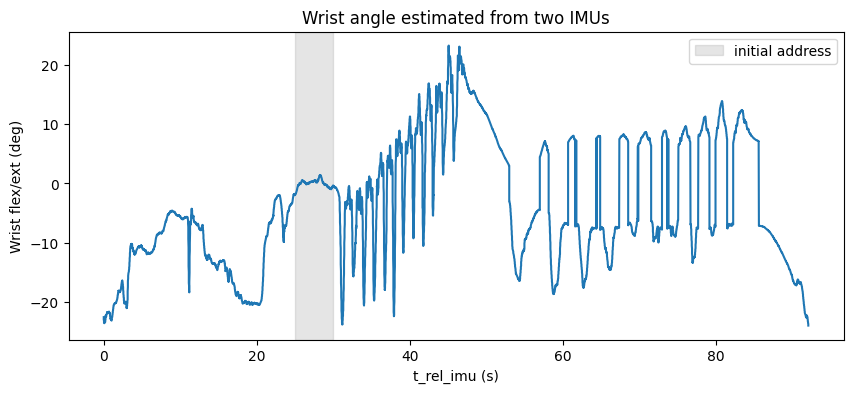

In [10]:

plt.figure(figsize=(10,4))
plt.plot(df["t_rel_imu"], df["wrist_angle_deg"])
plt.axvspan(25, 30, color="gray", alpha=0.2, label="initial address")
plt.xlabel("t_rel_imu (s)")
plt.ylabel("Wrist flex/ext (deg)")
plt.legend()
plt.title("Wrist angle estimated from two IMUs")
plt.show()
